<a href="https://colab.research.google.com/github/ArthurCBx/Applied_MachineLearning_in_Python/blob/main/Module2/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/ArthurCBx/Applied_MachineLearning_in_Python.git

Cloning into 'Applied_MachineLearning_in_Python'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 35 (delta 3), reused 23 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 10.22 MiB | 13.46 MiB/s, done.
Resolving deltas: 100% (3/3), done.


# Assignment 2

In this assignment you'll explore the relationship between model complexity and generalization performance, by adjusting key parameters of various supervised learning models. Part 1 of this assignment will look at regression and Part 2 will look at classification.

## Part 1 - Regression

X =  [ 0.35281047  0.79431716  1.62431903  2.59103578  3.23065446  3.375973
  4.47573197  4.96972856  5.69364194  6.51069113  7.17166586  8.14799756
  8.72363612  9.31004929 10.08877265] 

Y =  [ 0.43770571  0.99517935  1.24877201  0.98630796  0.36408873  0.07512287
 -0.16081    -0.05233879  0.3187423   1.53763897  1.82595557  2.31966323
  2.08031157  1.81942995  1.21213026] 



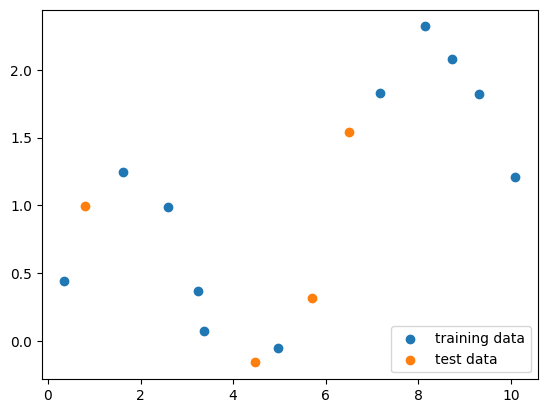

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


np.random.seed(0)
n = 15
x = np.linspace(0,10,n) + np.random.randn(n)/5
y = np.sin(x)+x/6 + np.random.randn(n)/10

print('X = ',x,'\n')
print('Y = ',y,'\n')
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(x, y, random_state=0)

def intro():
  plt.figure()
  plt.scatter(X_train_original, y_train_original, label='training data')
  plt.scatter(X_test_original, y_test_original, label='test data')
  plt.legend(loc=4);

intro()

### Question 1

Write a function that fits a polynomial LinearRegression model on the *training data* `X_train` for degrees 1, 3, 6, and 9. (Use PolynomialFeatures in sklearn.preprocessing to create the polynomial features and then fit a linear regression model) For each model, find 100 predicted values over the interval x = 0 to 10 (e.g. `np.linspace(0,10,100)`) and store this in a numpy array. The first row of this array should correspond to the output from the model trained on degree 1, the second row degree 3, the third row degree 6, and the fourth row degree 9.


*This function should return a numpy array with shape `(4, 100)`*

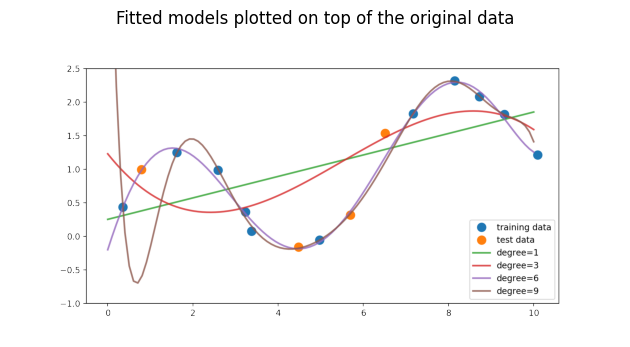

In [4]:
from PIL import Image
image = Image.open('/content/Applied_MachineLearning_in_Python/Module2/Assets/polynomialreg1.png')
plt.title('Fitted models plotted on top of the original data')
plt.imshow(image);
plt.box(False)
plt.xticks([])
plt.yticks([]);
plt.tight_layout()

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
to_predict_data = np.linspace(0, 10, 100).reshape(-1, 1)
x_reshaped = x.reshape(-1, 1)
degrees = [1, 3, 6, 9]
results = np.zeros((4, 100))
for i, degree in enumerate(degrees):
  poly = PolynomialFeatures(degree=degree)

  X_transformed = poly.fit_transform(x_reshaped)
  to_predict_data_transformed = poly.fit_transform(to_predict_data)
  X_train, X_test, y_train, y_test = train_test_split(X_transformed, y,random_state=0)

  model = LinearRegression().fit(X_train,y_train)
  results[i] = model.predict(to_predict_data_transformed)
results.shape

(4, 100)

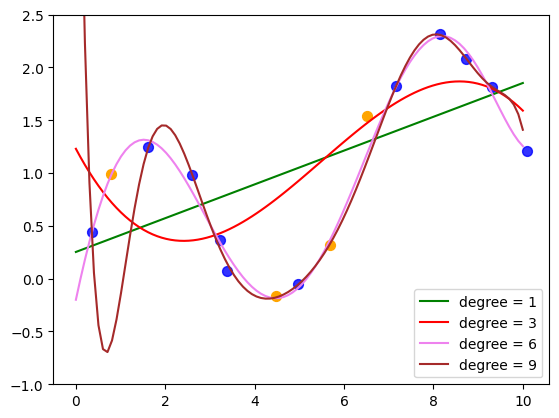

In [6]:
plt.plot(to_predict_data,results[0],'green',label='degree = 1')
plt.plot(to_predict_data,results[1],'red',label='degree = 3')
plt.plot(to_predict_data,results[2],'violet',label='degree = 6')
plt.plot(to_predict_data,results[3],'brown',label='degree = 9')
plt.scatter(X_train_original,y_train_original, c='blue',alpha=0.8,s=50)
plt.scatter(X_test_original,y_test_original,c='orange',s=50)
plt.ylim(-1,2.5)
plt.legend();

### Question 2

Write a function that fits a polynomial LinearRegression model on the training data `X_train` for degrees 0 through 9. For each model compute the $R^2$ (coefficient of determination) regression score on the training data as well as the the test data, and return both of these arrays in a tuple.

*This function should return a tuple of numpy arrays `(r2_train, r2_test)`. Both arrays should have shape `(10,)`*

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

degrees = np.linspace(0,9,10)
r2_train = np.zeros((10))
r2_test = np.zeros((10))
x_reshaped = x.reshape(-1, 1)

for i, degree in enumerate(degrees):
  # Create the polynomial model
  poly = PolynomialFeatures(degree=int(degree))

  # Transform data to fit in the poly version
  X_transformed = poly.fit_transform(x_reshaped)
  X_train,X_test, y_train, y_test = train_test_split(X_transformed,y,random_state=0)

  # Fit the model and use it to predict
  estimator = LinearRegression().fit(X_train, y_train)
  y_pred_train = estimator.predict(X_train)
  y_pred_test = estimator.predict(X_test)

  r2_train[i] = r2_score(y_train, y_pred_train)
  r2_test[i] = r2_score(y_test,y_pred_test)
answer = (r2_train, r2_test)

answer

(array([0.        , 0.42924578, 0.4510998 , 0.58719954, 0.91941945,
        0.97578641, 0.99018233, 0.99352509, 0.99637545, 0.99803706]),
 array([-0.47808642, -0.45237104, -0.06856984,  0.00533105,  0.73004943,
         0.87708301,  0.9214094 ,  0.92021504,  0.63247948, -0.64525365]))

### Question 3

Based on the $R^2$ scores from question 2 (degree levels 0 through 9), what degree level corresponds to a model that is underfitting? What degree level corresponds to a model that is overfitting? What choice of degree level would provide a model with good generalization performance on this dataset?

(Hint: Try plotting the $R^2$ scores from question 2 to visualize the relationship)

*This function should return a tuple with the degree values in this order: `(Underfitting, Overfitting, Good_Generalization)`*

(3, 9, 6)

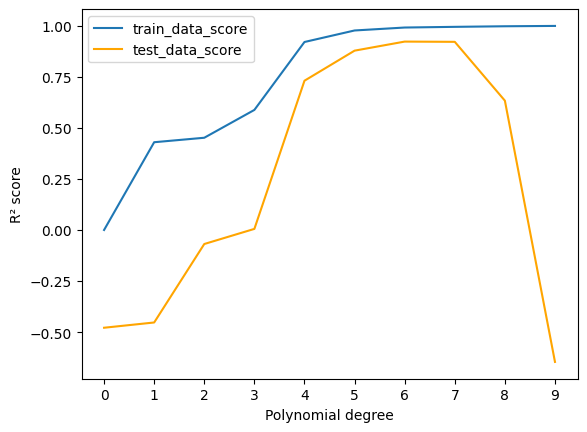

In [8]:
plt.plot(degrees,answer[0],label='train_data_score')
plt.plot(degrees,answer[1],label='test_data_score',c='orange')
plt.xticks([0,1,2,3,4,5,6,7,8,9])
plt.xlabel('Polynomial degree')
plt.ylabel('R² score')
plt.legend();
answer_three = (3, 9, 6)
answer_three

### Question 4

Training models on high degree polynomial features can result in overfitting. Train two models: a non-regularized LinearRegression model and a Lasso Regression model (with parameters `alpha=0.01`, `max_iter=10000`, `tol=0.1`) on polynomial features of degree 12. Return the $R^2$ score for LinearRegression and Lasso model's test sets.

*This function should return a tuple `(LinearRegression_R2_test_score, Lasso_R2_test_score)`*

In [9]:
from sklearn.linear_model import Lasso

x_reshaped = x.reshape(-1, 1)

# Transforming the data to fit polynomial of degree 12
poly = PolynomialFeatures(degree=12)
x_transformed = poly.fit_transform(x_reshaped)
X_train, X_test, y_train, y_test = train_test_split(x_transformed, y,random_state=0)

# Fitting and predicting Linear Regression model without regularization
linear_model = LinearRegression().fit(X_train, y_train)
y_pred_test = linear_model.predict(X_test)
LinearRegression_R2_test_score = r2_score(y_test, y_pred_test)

# Fitting and predicting Lasso model
lasso_model = Lasso(alpha=0.01,max_iter=10000,tol=0.1)
lasso_model.fit(X_train, y_train)
y_pred_test = lasso_model.predict(X_test)
Lasso_R2_test_score = r2_score(y_test, y_pred_test)

(LinearRegression_R2_test_score, Lasso_R2_test_score)

(-4.311996022859516, 0.6051396919570032)

## Part 2 - Classification

For this section of the assignment we will be working with the [UCI Mushroom Data Set](http://archive.ics.uci.edu/ml/datasets/Mushroom?ref=datanews.io) stored in `mushrooms.csv`. The data will be used to train a model to predict whether or not a mushroom is poisonous. The following attributes are provided:

*Attribute Information:*

1. cap-shape: bell=b, conical=c, convex=x, flat=f, knobbed=k, sunken=s
2. cap-surface: fibrous=f, grooves=g, scaly=y, smooth=s
3. cap-color: brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y
4. bruises?: bruises=t, no=f
5. odor: almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s
6. gill-attachment: attached=a, descending=d, free=f, notched=n
7. gill-spacing: close=c, crowded=w, distant=d
8. gill-size: broad=b, narrow=n
9. gill-color: black=k, brown=n, buff=b, chocolate=h, gray=g, green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y
10. stalk-shape: enlarging=e, tapering=t
11. stalk-root: bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, missing=?
12. stalk-surface-above-ring: fibrous=f, scaly=y, silky=k, smooth=s
13. stalk-surface-below-ring: fibrous=f, scaly=y, silky=k, smooth=s
14. stalk-color-above-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
15. stalk-color-below-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
16. veil-type: partial=p, universal=u
17. veil-color: brown=n, orange=o, white=w, yellow=y
18. ring-number: none=n, one=o, two=t
19. ring-type: cobwebby=c, evanescent=e, flaring=f, large=l, none=n, pendant=p, sheathing=s, zone=z
20. spore-print-color: black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y
21. population: abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y
22. habitat: grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d

<br>

The data in the mushrooms dataset is currently encoded with strings. These values will need to be encoded to numeric to work with sklearn. We'll use pd.get_dummies to convert the categorical variables into indicator variables.

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


mush_df = pd.read_csv('Applied_MachineLearning_in_Python/Module2/Assets/mushrooms.csv')
mush_df2 = pd.get_dummies(mush_df)

X_mush = mush_df2.iloc[:,2:]
y_mush = mush_df2.iloc[:,1]


X_train2, X_test2, y_train2, y_test2 = train_test_split(X_mush, y_mush, random_state=0)

In [11]:
mush_df2

,class_e,class_p,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,True,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,True,False
1,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,True,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,True,False
4,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,True,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
8120,True,False,False,False,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False
8121,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
8122,False,True,False,False,False,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False


### Question 5

Using `X_train` and `y_train` from the preceeding cell, train a DecisionTreeClassifier with default parameters and random_state=0. What are the 5 most important features found by the decision tree?

*This function should return a list of length 5 of the feature names in descending order of importance.*

In [12]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=0).fit(X_train2, y_train2)
feature_keys = tree.feature_importances_.argsort()
top_five_reversed = feature_keys[-5:]
top_five = top_five_reversed[::-1]
answer = list(X_train2.columns[top_five])


In [13]:
feature_keys

array([  0,   2,   3,   4,   6,   5,   9,   8,  12,  13,  10,  11,  14,
        15,  17,  16,  30,  26,  18,  19,  20,  21,  23,  24,  31,  28,
        29,  37,  35,  34,  33,  32,  60,  49,  50,  51,  52,  38,  39,
        40,  44,  41,  42,  43,  46,  45,  47,  48,  62,  61,  58,  59,
        57,  54,  56,  76,  72,  70,  69,  68,  67,  66,  65,  64, 116,
        97,  98,  99, 101, 102, 103, 104, 111,  73,  74,  75,  78,  77,
        79,  80,  88,  81,  82,  83,  84,  85,  86,  87,  92,  89,  90,
        91,  94,  93,  95,  96, 115, 106, 107, 108, 110, 114, 113, 112,
        36,   1, 105,   7, 109,  63,  71,  22,  25, 100,  55,  53,  27])

### Question 6

For this question, use the `validation_curve` function in `sklearn.model_selection` to determine training and test scores for a Support Vector Classifier (`SVC`) with varying parameter values.

Create an `SVC` with default parameters (i.e. `kernel='rbf', C=1`) and `random_state=0`. Recall that the kernel width of the RBF kernel is controlled using the `gamma` parameter.  Explore the effect of `gamma` on classifier accuracy by using the `validation_curve` function to find the training and test scores for 6 values of `gamma` from `0.0001` to `10` (i.e. `np.logspace(-4,1,6)`).

For each level of `gamma`, `validation_curve` will use 3-fold cross validation (use `cv=3, n_jobs=2` as parameters for `validation_curve`), returning two 6x3 (6 levels of gamma x 3 fits per level) arrays of the scores for the training and test sets in each fold.

Find the mean score across the five models for each level of `gamma` for both arrays, creating two arrays of length 6, and return a tuple with the two arrays.

e.g.

if one of your array of scores is

    array([[ 0.5,  0.4,  0.6],
           [ 0.7,  0.8,  0.7],
           [ 0.9,  0.8,  0.8],
           [ 0.8,  0.7,  0.8],
           [ 0.7,  0.6,  0.6],
           [ 0.4,  0.6,  0.5]])
       
it should then become

    array([ 0.5,  0.73333333,  0.83333333,  0.76666667,  0.63333333, 0.5])

*This function should return a tuple of numpy arrays `(training_scores, test_scores)` where each array in the tuple has shape `(6,)`.*

In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import validation_curve

gammas = np.logspace(-4,1,6)
train_score_total, test_score_total = validation_curve(SVC(kernel='rbf',C=1, random_state=0),
                                          X=X_mush, y=y_mush,
                                          param_name='gamma',
                                          param_range=gammas,
                                          cv=3, n_jobs=2)
train_score = np.zeros(6)
test_score = np.zeros(6)
for i, row in enumerate(train_score_total):
  train_score[i] = row.mean()

for i, row in enumerate(test_score_total):
  test_score[i] = row.mean()

train_score, test_score

(array([0.89838749, 0.98104382, 0.99895372, 1.        , 1.        ,
        1.        ]),
 array([0.88749385, 0.82951748, 0.84170359, 0.86582964, 0.83616445,
        0.51797144]))

In [26]:
train_score.shape

(6,)

### Question 7

Based on the scores from question 6, what gamma value corresponds to a model that is underfitting? What gamma value corresponds to a model that is overfitting? What choice of gamma would provide a model with good generalization performance on this dataset?

(Hint: Try plotting the scores from question 6 to visualize the relationship)

*This function should return a tuple with the degree values in this order: `(Underfitting, Overfitting, Good_Generalization)`*

In [36]:
(1e-3, 1e1, 1e-1)

(0.0001, 10.0, 0.1)

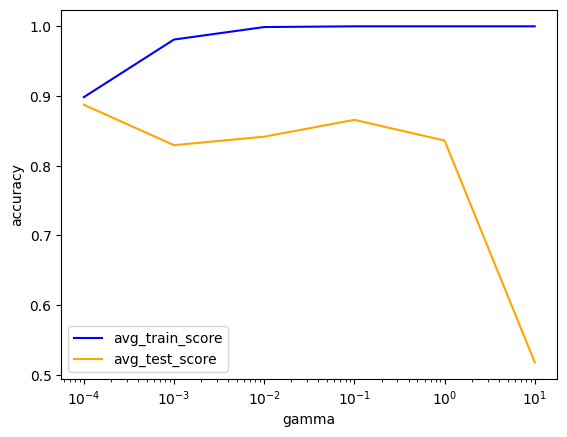

In [34]:
plt.plot(gammas, train_score, label ='avg_train_score', c='blue')
plt.plot(gammas, test_score, label = 'avg_test_score', c='orange')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('accuracy')
plt.legend();

In [28]:
gammas

array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01])